# Validating Rearview's numbers

An independent reimplementation, in pandas, of the figures Rearview shows. It shares no code with the app (`code/` is JavaScript); it only follows the definitions on the **Docs** tab. If both arrive at the same numbers from the same file, neither one is quietly wrong.

It reads the public sample, `sample/sample_delivery_information.csv`: the author's own export with store names replaced by codes and every date moved back a whole number of weeks (see `analysis/deidentify.py`). Weekdays and times of day are unchanged, so every figure matches the original file.

Three parts:

1. **Reproduce** the README figures and the app's counts.
2. **How sure**: a bootstrap interval for the one comparison the README leans on, the eight minutes a same-store stack costs the second customer.
3. **How much rides on the one-hour rule** that splits a day into shifts.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

TZ = "America/Los_Angeles"
SRC = Path("../sample/sample_delivery_information.csv")
COLUMNS = ["ORDER_CREATED_TIME", "ACTUAL_PICKUP_TIME", "ACTUAL_DELIVERY_TIME", "STORE_NAME"]

# What the app shows for this file, copied from the running app.
APP = {
    "orders": 465, "trips": 352, "solo orders": 242, "two-order trips": 109,
    "shifts": 84, "dash hours": 178.411, "scheduled orders": 18,
    "order time, median min": 30.933, "repeat stores, %": 39,
    "solo leg, median min": 13.575, "same-store second drop, median min": 21.633,
    "same-store stacks": 37,
}

## Reading the file

The same rules as the app: timestamps are UTC with no marker, seconds are truncated (the app ignores the fractional part), and every calendar question is answered in the dasher's zone. A row is dropped if a time will not parse, if it was dropped off before it was picked up, if it was picked up before it was created, or if it repeats another row exactly.

In [2]:
raw = pd.read_csv(SRC, dtype=str)[COLUMNS]

def utc(col):
    # "2025-07-05 22:25:29.400000000" -> 22:25:29, as the app's parseUtc does.
    return pd.to_datetime(raw[col].str.strip().str[:19], format="%Y-%m-%d %H:%M:%S", errors="coerce", utc=True)

df = pd.DataFrame({
    "created": utc("ORDER_CREATED_TIME"),
    "pickup": utc("ACTUAL_PICKUP_TIME"),
    "delivery": utc("ACTUAL_DELIVERY_TIME"),
    "store": raw["STORE_NAME"].str.strip(),
})
ok = (df[["created", "pickup", "delivery"]].notna().all(axis=1)
      & (df.delivery >= df.pickup) & (df.pickup >= df.created)
      & ~raw.duplicated())
print(f"{len(raw)} rows, {int((~ok).sum())} rejected")

df = df[ok].sort_values("pickup", kind="stable").reset_index(drop=True)
mins = lambda a, b: (b - a).dt.total_seconds() / 60
df["to_pickup"] = mins(df.created, df.pickup)     # created -> pickup
df["leg"] = mins(df.pickup, df.delivery)          # pickup -> drop off
df["total"] = mins(df.created, df.delivery)       # created -> drop off: what the customer waited
df["scheduled"] = df.to_pickup > 60               # placed ahead, so its wait is not a wait
df["local"] = df.pickup.dt.tz_convert(TZ)

465 rows, 0 rejected


## Trips

A trip is every order that was in the car at the same time: one order joins another if it was picked up before the other was dropped off. The test is strict (`<`), and it is transitive, so a relay of overlapping orders is one trip.

In [3]:
def build_trips(df):
    parent = list(range(len(df)))
    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x
    pick, drop = df.pickup.to_numpy(), df.delivery.to_numpy()
    for i in range(len(df)):
        for j in range(i + 1, len(df)):
            if pick[j] >= drop[i]:
                break               # sorted by pickup: nothing later overlaps order i
            parent[find(i)] = find(j)
    roots = [find(i) for i in range(len(df))]
    # Number trips by their first pickup, as the app does.
    first = pd.Series(df.pickup.values, index=roots).groupby(level=0).min().sort_values(kind="stable")
    order = {r: k for k, r in enumerate(first.index)}
    return pd.Series([order[r] for r in roots], index=df.index)

df["trip"] = build_trips(df)
df["trip_size"] = df.groupby("trip").trip.transform("size")

trips = df.groupby("trip").agg(start=("pickup", "min"), end=("delivery", "max"),
                               size=("trip", "size"), stores=("store", "nunique"))
trips["span"] = mins(trips.start, trips.end)
trips["min_per_order"] = trips.span / trips["size"]
trips["size"].value_counts().sort_index()

size
1    242
2    109
5      1
Name: count, dtype: int64

## Shifts

A new shift starts after a gap of more than an hour between one trip's last drop and the next trip's first pickup. The shift runs from its first pickup to its last drop, and it belongs to the day of that first pickup. The rule is Rearview's, not DoorDash's; part 3 tests how much depends on it.

In [4]:
def build_shifts(trips, gap_min=60):
    rows, cur = [], None
    for t in trips.itertuples():
        if cur is not None and (t.start - cur["end"]).total_seconds() / 60 <= gap_min:
            cur["end"] = max(cur["end"], t.end)
            cur["orders"] += t.size
        else:
            cur = {"start": t.start, "end": t.end, "orders": t.size}
            rows.append(cur)
    s = pd.DataFrame(rows)
    s["minutes"] = mins(s.start, s.end)
    s["day"] = s.start.dt.tz_convert(TZ).dt.date
    return s

shifts = build_shifts(trips)
len(shifts), round(shifts.minutes.sum() / 60, 3)

(84, np.float64(178.411))

## 1. Reproducing the figures

In [5]:
solo = df[df.trip_size == 1]

# Same-store stacks: two-order trips from one counter. The customer who waited
# more is the one dropped second.
pairs = df[df.trip_size == 2].groupby("trip")
same_store = pairs.filter(lambda g: g.store.nunique() == 1)
second_drop = same_store.sort_values("delivery", kind="stable").groupby("trip").tail(1)

mine = {
    "orders": len(df),
    "trips": len(trips),
    "solo orders": len(solo),
    "two-order trips": int((trips["size"] == 2).sum()),
    "shifts": len(shifts),
    "dash hours": shifts.minutes.sum() / 60,
    "scheduled orders": int(df.scheduled.sum()),
    "order time, median min": df.loc[~df.scheduled, "total"].median(),
    "repeat stores, %": round(100 * (len(df) - df.store.nunique()) / len(df)),
    "solo leg, median min": solo.leg.median(),
    "same-store second drop, median min": second_drop.leg.median(),
    "same-store stacks": len(second_drop),
}
check = pd.DataFrame({"app": APP, "notebook": mine})
check["match"] = np.isclose(check.app.astype(float), check.notebook.astype(float), atol=0.001)
check.style.format({"app": "{:g}", "notebook": "{:.3f}"})

,app,notebook,match
orders,465,465.000,True
trips,352,352.000,True
solo orders,242,242.000,True
two-order trips,109,109.000,True
shifts,84,84.000,True
dash hours,178.411,178.411,True
scheduled orders,18,18.000,True
"order time, median min",30.933,30.933,True
"repeat stores, %",39,39.000,True
"solo leg, median min",13.575,13.575,True


In [6]:
assert check.match.all(), check[~check.match]
cost = mine["same-store second drop, median min"] - mine["solo leg, median min"]
print(f"All {len(check)} figures match. A same-store stack costs the second customer "
      f"{cost:.1f} min over a solo drop ({mine['same-store second drop, median min']:.1f} vs "
      f"{mine['solo leg, median min']:.1f}).")

All 12 figures match. A same-store stack costs the second customer 8.1 min over a solo drop (21.6 vs 13.6).


### How much of the dash time the file recovers

The export records orders, not the time spent waiting for them, so shifts built from order gaps can only undercount. One DoorDash weekly statement is available to check against: the last full Monday-to-Sunday week in the file, which reported **33 h 29 min** dashing and **23 h 51 min** active.

This is **based on one statement week**. With a single week there is nothing to put a confidence interval on; the figure says how far off the estimate was that week, not how far off it will be.

In [7]:
STATEMENT = {"dash": 33 * 60 + 29, "active": 23 * 60 + 51, "deliveries": 81}

last_day = df.local.dt.date.max()
sunday = last_day - pd.Timedelta(days=(last_day.weekday() + 1) % 7)
week = pd.date_range(sunday - pd.Timedelta(days=6), sunday).date

def union_minutes(spans):
    total, lo, hi = 0.0, None, None
    for a, b in sorted(spans):
        if lo is None:
            lo, hi = a, b
        elif a <= hi:
            hi = max(hi, b)
        else:
            total += (hi - lo).total_seconds(); lo, hi = a, b
    if lo is not None:
        total += (hi - lo).total_seconds()
    return total / 60

in_week = df[df.local.dt.date.isin(week)]
dash = shifts.loc[shifts.day.isin(week), "minutes"].sum()
active = union_minutes(zip(in_week.pickup, in_week.delivery))
hm = lambda m: f"{int(m // 60)} h {int(round(m % 60)):02d} min"

print(f"Deliveries that week: {len(in_week)} (statement: {STATEMENT['deliveries']})")
print(f"Dash time:   {hm(dash)} of {hm(STATEMENT['dash'])}  -> {dash / STATEMENT['dash']:.0%} recovered")
print(f"Active time: {hm(active)} of {hm(STATEMENT['active'])}  -> {active / STATEMENT['active']:.0%} recovered")

Deliveries that week: 81 (statement: 81)
Dash time:   30 h 30 min of 33 h 29 min  -> 91% recovered
Active time: 17 h 36 min of 23 h 51 min  -> 74% recovered


## 2. How sure is the eight minutes?

The comparison is 37 same-store stacks against 242 solo orders. A bootstrap resamples each group with replacement and recomputes the difference in medians, 10,000 times.

The unit resampled is the **stacked trip**, not the order: each of the 37 stacks contributes one second drop, so a stack is drawn whole or not at all. Solo orders are resampled on their own. The seed is fixed so the interval is the same on every run.

In [8]:
rng = np.random.default_rng(20260829)
B = 10_000
stack_legs = second_drop.leg.to_numpy()     # one value per stacked trip
solo_legs = solo.leg.to_numpy()

diffs = np.array([
    np.median(rng.choice(stack_legs, stack_legs.size)) - np.median(rng.choice(solo_legs, solo_legs.size))
    for _ in range(B)
])
lo, hi = np.percentile(diffs, [2.5, 97.5])
print(f"Second drop minus solo: {cost:.1f} min, 95% interval {lo:.1f} to {hi:.1f} "
      f"({stack_legs.size} stacks, {solo_legs.size} solo orders, {B:,} resamples)")
print(f"Share of resamples where the stack was not slower: {(diffs <= 0).mean():.1%}")

Second drop minus solo: 8.1 min, 95% interval 5.9 to 11.0 (37 stacks, 242 solo orders, 10,000 resamples)
Share of resamples where the stack was not slower: 0.0%


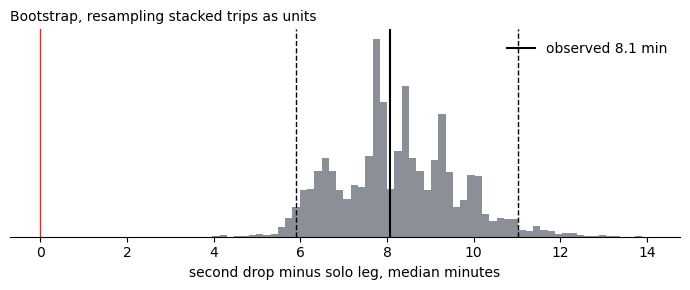

In [9]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(diffs, bins=60, color="#8a8f98")
ax.axvline(cost, color="black", lw=1.5, label=f"observed {cost:.1f} min")
for x in (lo, hi):
    ax.axvline(x, color="black", lw=1, ls="--")
ax.axvline(0, color="#c0392b", lw=1)
ax.set_xlabel("second drop minus solo leg, median minutes")
ax.set_yticks([])
ax.set_title("Bootstrap, resampling stacked trips as units", loc="left", fontsize=10)
ax.legend(frameon=False)
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
plt.tight_layout()

## 3. How much rides on the one-hour rule?

A gap of more than 60 minutes between trips starts a new shift. The rule is a judgement call: a long wait between offers and going home for lunch look the same in the file. The same pipeline is run with the threshold at 30, 45, 60, 90 and 120 minutes.

Trips, order time, legs and the stacking comparison do not use shifts at all, so they do not move. What moves is the shift count, the dash hours, and anything per dash hour.

In [10]:
rows = []
for gap in (30, 45, 60, 90, 120):
    s = build_shifts(trips, gap)
    week_min = s.loc[s.day.isin(week), "minutes"].sum()
    rows.append({"gap, min": gap, "shifts": len(s), "dash hours": s.minutes.sum() / 60,
                 "orders per dash hour": len(df) / (s.minutes.sum() / 60),
                 "statement week recovered": week_min / STATEMENT["dash"]})
sens = pd.DataFrame(rows).set_index("gap, min")
sens.style.format({"dash hours": "{:.1f}", "orders per dash hour": "{:.2f}",
                   "statement week recovered": "{:.0%}"})

,shifts,dash hours,orders per dash hour,statement week recovered
"gap, min",,,,
30,116,159.4,2.92,86%
45,88,175.0,2.66,91%
60,84,178.4,2.61,91%
90,83,179.5,2.59,91%
120,82,181.0,2.57,91%


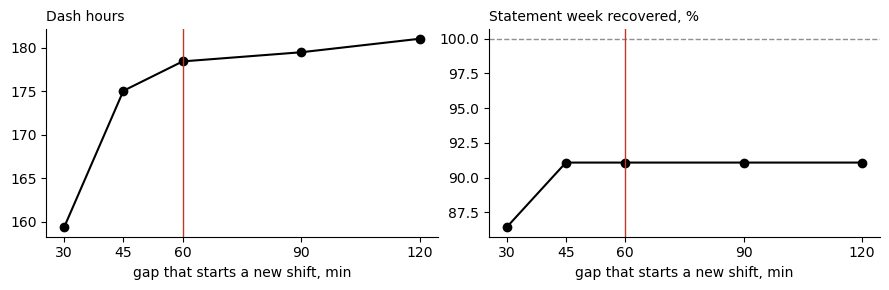

In [11]:
fig, (a, b) = plt.subplots(1, 2, figsize=(9, 3))
a.plot(sens.index, sens["dash hours"], marker="o", color="black")
a.set_title("Dash hours", loc="left", fontsize=10)
b.plot(sens.index, 100 * sens["statement week recovered"], marker="o", color="black")
b.axhline(100, color="#8a8f98", lw=1, ls="--")
b.set_title("Statement week recovered, %", loc="left", fontsize=10)
for ax in (a, b):
    ax.axvline(60, color="#c0392b", lw=1)
    ax.set_xticks(sens.index)
    ax.set_xlabel("gap that starts a new shift, min")
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
plt.tight_layout()

In [12]:
at = sens.loc[60, "dash hours"]
print(f"Halving the rule to 30 min: {sens.loc[30, 'dash hours'] - at:+.1f} dash hours "
      f"({sens.loc[30, 'dash hours'] / at - 1:+.0%}); doubling it to 120 min: "
      f"{sens.loc[120, 'dash hours'] - at:+.1f} ({sens.loc[120, 'dash hours'] / at - 1:+.0%}).")

Halving the rule to 30 min: -19.1 dash hours (-11%); doubling it to 120 min: +2.6 (+1%).


## What this does and does not show

- The app's figures follow from its stated definitions: an independent implementation reaches the same numbers from the same file.
- The stacking cost is the one comparison with enough data to put an interval on. It is one dasher in one area over two months, not a claim about stacking in general.
- It does not control for distance. Stacked orders may simply travel farther.
- Dash-time recovery is checked against a single statement week, so it is an observation, not an error rate.
- Any per-dash-hour figure inherits the shift rule; the table in part 3 shows how far it can move.